In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [52]:
df= pd.read_csv('placement.csv')

In [53]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


<Axes: xlabel='cgpa', ylabel='package'>

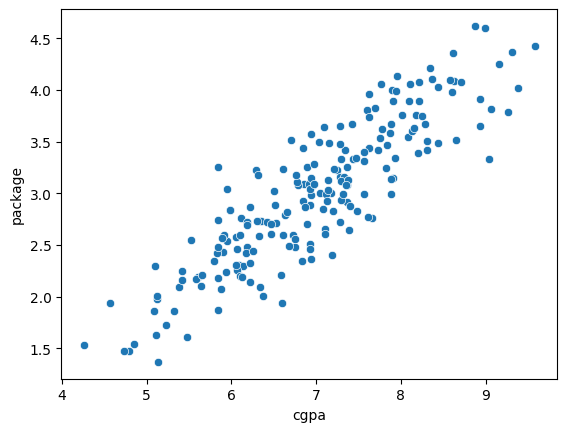

In [54]:
# drawing a scatter plot to see the relationship between variable
sns.scatterplot(x='cgpa',y='package',data=df)

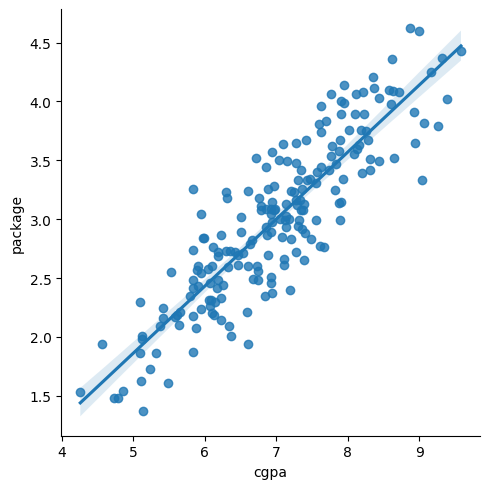

In [55]:
# creating a linear regression model to fit the data
sns.lmplot(x='cgpa',y='package',data=df)

In [56]:
# splitting the data into training and testing data
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [57]:
#importing the train_test_split function to split the data into training and testing data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
# fitting the linear regression model to the training data
lr = LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
#slope of the line
lr.coef_

array([0.55795197])

In [61]:
# intercept of the line
lr.intercept_

np.float64(-0.8961119222429144)

In [62]:
# predicting the Test Data
prediction = lr.predict(X_test)

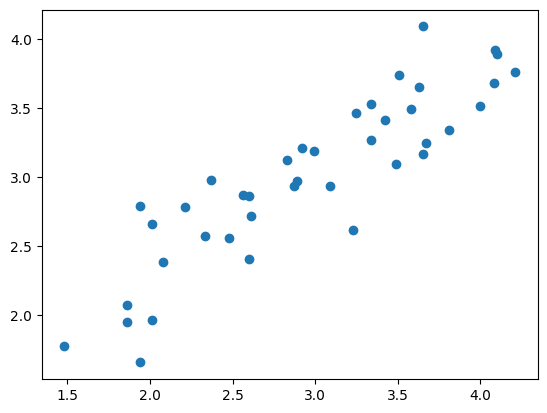

In [63]:
plt.scatter(y_test, prediction)

In [64]:
from sklearn import metrics

In [65]:
print('MAE',metrics.mean_absolute_error(y_test,prediction))
print('MSE',metrics.mean_squared_error(y_test,prediction))
print('RMSE',np.sqrt(metrics.mean_squared_error(y_test,prediction)))

MAE 0.2884710931878175
MSE 0.12129235313495527
RMSE 0.34827051717731616


In [66]:
# calculating R^2 score
print('R^2 score',metrics.r2_score(y_test,prediction))

R^2 score 0.780730147510384


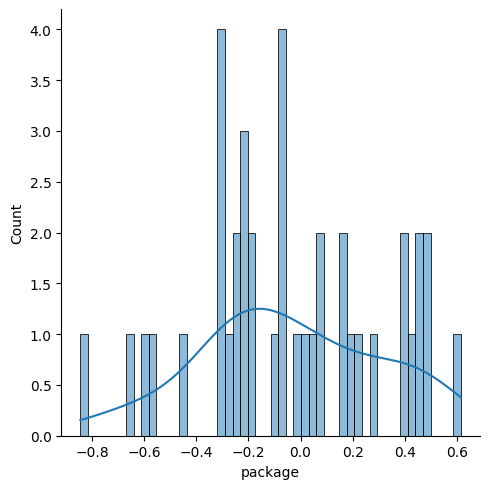

In [67]:
# Plotting a histogram of the residuals and make sure it looks normally distributed
sns.displot(y_test - prediction, bins=50, kde=True)